In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('processed_titanic_without_normalization.csv')
df.head(5)

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,num,HomePlanet_Europa,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
0,0001_01,39.0,0.0,0.0,0.0,0.0,0.0,False,0.0,True,...,True,False,True,False,False,False,False,False,False,False
1,0002_01,24.0,109.0,9.0,25.0,549.0,44.0,True,0.0,False,...,True,False,False,False,False,False,True,False,False,True
2,0003_01,58.0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,True,...,True,True,False,False,False,False,False,False,False,True
3,0003_02,33.0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,True,...,True,False,False,False,False,False,False,False,False,True
4,0004_01,16.0,303.0,70.0,151.0,565.0,2.0,True,1.0,False,...,True,False,False,False,False,False,True,False,False,True


In [3]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Transported'], axis=1), df['Transported'], test_size=0.4, random_state=42)

In [4]:
# Random Forest Classification

In [5]:
random_forest_model = RandomForestClassifier(oob_score=True)

#random_forest_model.fit(df.drop(['Transported'], axis=1), df['Transported'])
random_forest_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [6]:
oob_score = random_forest_model.oob_score_
oob_error = 1 - random_forest_model.oob_score_

print('OOB score:', oob_score)
print('OOB error:', oob_error)

OOB score: 0.8049856184084372
OOB error: 0.1950143815915628


In [7]:
y_pred = random_forest_model.predict(x_test)
y_proba = random_forest_model.predict_proba(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.78      0.81      0.80      1714
        True       0.81      0.78      0.79      1764

    accuracy                           0.80      3478
   macro avg       0.80      0.80      0.80      3478
weighted avg       0.80      0.80      0.80      3478



AUC: 0.8755083519210873


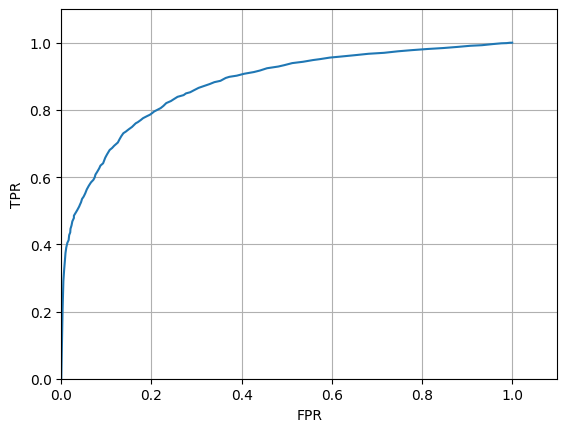

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])

print('AUC:', auc(fpr, tpr))

plt.plot(fpr, tpr)
plt.xlim([0, 1.1])
plt.ylim([0, 1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.grid()

In [9]:
# Adaptive Boosting Classifier

In [10]:
ada_boost_model = AdaBoostClassifier()

ada_boost_model.fit(x_train, y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [11]:
y_pred = ada_boost_model.predict(x_test)
y_proba = ada_boost_model.predict_proba(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.77      0.77      0.77      1714
        True       0.78      0.77      0.77      1764

    accuracy                           0.77      3478
   macro avg       0.77      0.77      0.77      3478
weighted avg       0.77      0.77      0.77      3478



AUC: 0.8566123454438175


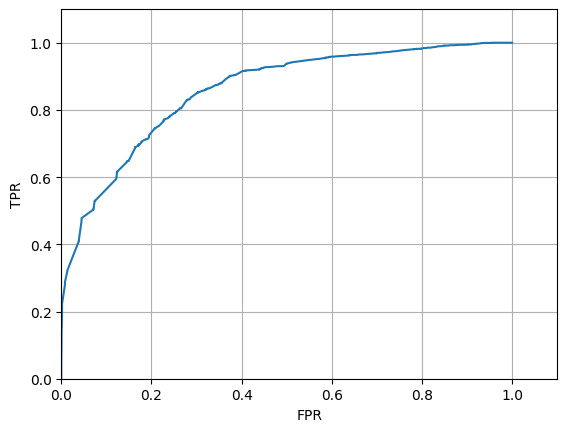

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])

print('AUC:', auc(fpr, tpr))

plt.plot(fpr, tpr)
plt.xlim([0, 1.1])
plt.ylim([0, 1.1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.grid()

In [13]:
# Gradient Boosting Classifier

In [14]:
grad_boost_model = GradientBoostingClassifier()

grad_boost_model.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [15]:
y_pred = grad_boost_model.predict(x_test)
y_proba = grad_boost_model.predict_proba(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.82      0.75      0.78      1714
        True       0.78      0.85      0.81      1764

    accuracy                           0.80      3478
   macro avg       0.80      0.80      0.80      3478
weighted avg       0.80      0.80      0.80      3478



AUC: 0.8919079105776888


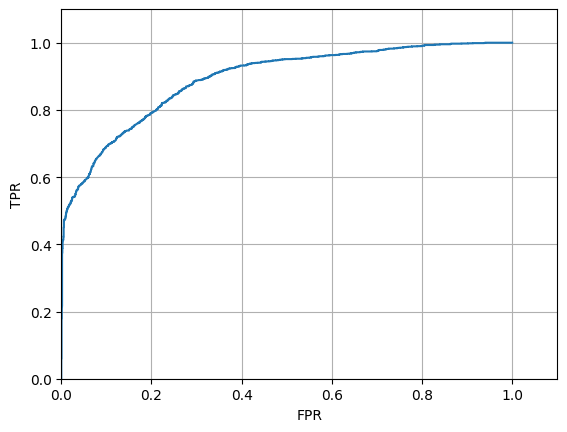

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])

print('AUC:', auc(fpr ,tpr))

plt.plot(fpr, tpr)
plt.xlim([0, 1.1])
plt.ylim([0, 1.1])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid()